#  Molecule Ideation Assistant
### Powered by NVIDIA BioNeMo (MolMIM) + Llama 3.3 70B (NVIDIA NIM)

**Domain:** Drug Discovery | **AI Approach:** Generative AI + LLM Reasoning

---
This project builds an AI-powered pipeline that takes a real FDA-approved drug (lead compound)
and generates optimised analog candidates under three simultaneous constraints:
-  **Potency** — QED score and binding likelihood
-  **Toxicity** — LogP, Lipinski rules, toxicity flags
-  **Synthesis feasibility** — Molecular weight and complexity

**Reduces analog ideation from weeks of manual effort to under 5 minutes.**

##  Step 1: Install Dependencies
Installing RDKit for molecular validation and OpenAI client for NVIDIA NIM API access.

In [1]:

!pip install rdkit pandas requests python-dotenv openai streamlit chembl-webresource-client -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.5 MB/s eta 0:00:00


## 🔑 Step 2: Load API Keys
- **NVIDIA_API_KEY** — for NVIDIA BioNeMo (MolMIM molecule generation)
- **LLAMA_API_KEY** — for Llama 3.3 70B via NVIDIA NIM (reasoning + ranking)

Keys are stored securely in Colab Secrets (not hardcoded).

In [2]:
from google.colab import userdata

# Check exact secret names available
import json

# Try these variations
try:
    k1 = userdata.get('LLAMA_API_KEY')
    print("LLAMA_API_KEY works:", "loaded")
except:
    print("LLAMA_API_KEY - NOT FOUND")

try:
    k2 = userdata.get('NVIDIA_API_KEY')
    print("NVIDIA_API_KEY works:", "loaded")
except:
    print("NVIDIA_API_KEY - NOT FOUND")

LLAMA_API_KEY works: loaded
NVIDIA_API_KEY works: loaded


##  Step 3: Full Pipeline
Three-stage pipeline:

| Stage | Tool | Role |
|-------|------|------|
| 1. Generate | NVIDIA BioNeMo MolMIM | Generate 10 analog candidates from lead SMILES |
| 2. Validate | RDKit | QED scoring, LogP, Lipinski rules, PAINS filtering, hERG cardiotoxicity screening, structural alert detection |
| 3. Rank | Llama 3.3 70B (NIM) | Rank top 3 with plain-English medicinal chemistry rationale |

In [6]:
import requests
import os
from google.colab import userdata

# Retrieve keys from userdata
llama_api_key = userdata.get('LLAMA_API_KEY')
nvidia_api_key = userdata.get('NVIDIA_API_KEY')

# Test LLAMA key on Llama endpoint
headers = {
    "Authorization": f"Bearer {llama_api_key}",
    "Content-Type": "application/json"
}

url = "https://integrate.api.nvidia.com/v1/chat/completions"

payload = {
    "model": "meta/llama-3.3-70b-instruct",
    "messages": [{"role": "user", "content": "say hello"}],
    "max_tokens": 10
}

response = requests.post(url, headers=headers, json=payload)
print("LLAMA key on Llama endpoint:", response.status_code)

# Test NVIDIA key on MolMIM endpoint
headers2 = {
    "Authorization": f"Bearer {nvidia_api_key}",
    "Content-Type": "application/json"
}

payload2 = {
    "smi": "CC(=O)Oc1ccccc1C(=O)O",
    "num_molecules": 3,
    "property_name": "QED",
    "minimize": False,
    "min_similarity": 0.3,
    "particles": 30,
    "iterations": 10
}

url2 = "https://health.api.nvidia.com/v1/biology/nvidia/molmim/generate"
response2 = requests.post(url2, headers=headers2, json=payload2)
print("NVIDIA key on MolMIM endpoint:", response2.status_code)

LLAMA key on Llama endpoint: 200
NVIDIA key on MolMIM endpoint: 200


##  Step 4: Pipeline Functions + Initial Test (Aspirin)
Defining all three pipeline functions and running an initial test on Aspirin as the lead compound.

In [4]:
import requests
import os
import json
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from google.colab import userdata

# Retrieve API keys from Colab's user data and set them as environment variables
os.environ['NVIDIA_API_KEY'] = userdata.get('NVIDIA_API_KEY')
os.environ['LLAMA_API_KEY'] = userdata.get('LLAMA_API_KEY')

# ============================================
# STEP 1: GENERATE ANALOGS VIA MOLMIM
# ============================================
def generate_analogs(smiles, num_samples=10):
    url = "https://health.api.nvidia.com/v1/biology/nvidia/molmim/generate"
    headers = {
        "Authorization": f"Bearer {os.environ['NVIDIA_API_KEY']}",
        "Content-Type": "application/json"
    }
    payload = {
        "smi": smiles,
        "num_molecules": num_samples,
        "property_name": "QED",
        "minimize": False,
        "min_similarity": 0.3,
        "particles": 30,
        "iterations": 10
    }
    response = requests.post(url, headers=headers, json=payload)
    if response.status_code == 200:
        return response.json()
    else:
        print("MolMIM Error:", response.status_code, response.text)
        return None

# ============================================
# STEP 2: VALIDATE + SCORE VIA RDKIT
# ============================================
def validate_and_score(smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        qed = QED.qed(mol)

        # Lipinski rule of 5
        lipinski = mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10

        # Simple toxicity flag based on logP
        if logp > 5:
            tox_flag = "⚠️ WARN - High lipophilicity"
        elif logp < 0:
            tox_flag = "⚠️ WARN - Too hydrophilic"
        else:
            tox_flag = "✅ PASS"

        # Synthesis score (SA approximation)
        synth_score = "✅ Easy" if mw < 300 else "⚠️ Moderate" if mw < 450 else "❌ Complex"

        results.append({
            "smiles": smi,
            "mol_weight": round(mw, 2),
            "logP": round(logp, 2),
            "QED": round(qed, 3),
            "lipinski": "✅ PASS" if lipinski else "❌ FAIL",
            "toxicity": tox_flag,
            "synthesis": synth_score
        })
    return results

# ============================================
# STEP 3: RANK + EXPLAIN VIA LLAMA 3.3
# ============================================
def rank_with_llama(lead_smiles, candidates):
    url = "https://integrate.api.nvidia.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {os.environ['LLAMA_API_KEY']}",
        "Content-Type": "application/json"
    }

    candidate_text = "\n".join([
        f"{i+1}. SMILES: {c['smiles']} | MW: {c['mol_weight']} | LogP: {c['logP']} | QED: {c['QED']} | Lipinski: {c['lipinski']} | Toxicity: {c['toxicity']} | Synthesis: {c['synthesis']}"
        for i, c in enumerate(candidates)
    ])

    prompt = f"""You are an expert medicinal chemist AI assistant.\n\nLead compound SMILES: {lead_smiles}\n\nThe following analog candidates were generated. Rank the TOP 3 and explain why each is a good drug candidate based on potency (QED score), toxicity (LogP, toxicity flag), and synthesis feasibility.\n\nCandidates:\n{candidate_text}\n\nFor each of your top 3, provide:\n- Rank and SMILES\n- Why it's promising (potency, safety, synthesisability)\n- Any concerns\n\nBe concise and clear."""

    payload = {
        "model": "meta/llama-3.3-70b-instruct",
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 800,
        "temperature": 0.3
    }

    response = requests.post(url, headers=headers, json=payload)
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"]
    else:
        print("Llama Error:", response.status_code, response.text)
        return None

# ============================================
# RUN THE FULL PIPELINE
# ============================================
lead = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin
print("=" * 50)
print(f"Lead Compound: {lead}")
print("=" * 50)

print("\n Step 1: Generating analogs via MolMIM...")
result = generate_analogs(lead, num_samples=10)
# Parse the 'molecules' string into a Python list and extract 'sample' (SMILES)
smiles_list = [item["sample"] for item in json.loads(result["molecules"])]
print(f" {len(smiles_list)} analogs generated")

print("\n Step 2: Validating via RDKit...")
scored = validate_and_score(smiles_list)
print(f" {len(scored)} valid candidates scored")

print("\n Step 3: Ranking via Llama 3.3...")
explanation = rank_with_llama(lead, scored)
print("\n" + "=" * 50)
print("FINAL RANKED OUTPUT:")
print("=" * 50)
print(explanation)


Lead Compound: CC(=O)Oc1ccccc1C(=O)O

 Step 1: Generating analogs via MolMIM...
 10 analogs generated

 Step 2: Validating via RDKit...
 10 valid candidates scored

 Step 3: Ranking via Llama 3.3...

FINAL RANKED OUTPUT:
Here are my top 3 ranked candidates:

**1. SMILES: O=C(O)c1ccccc1C(F)(F)Oc1ccccc1Cl**
This candidate is promising due to its high QED score (0.921), indicating strong potency. Its LogP value (4.17) is relatively high, but still within acceptable limits. The ease of synthesis and passing toxicity and Lipinski filters make it a strong contender. Concern: potential for high lipophilicity-related side effects.

**2. SMILES: O=C(O)c1ccccc1-c1ccccc1OC(F)F**
This candidate has a high QED score (0.916) and a moderate LogP value (3.65), suggesting a good balance between potency and safety. Its ease of synthesis and passing filters also make it a promising candidate. Concern: potential for metabolic instability due to the presence of multiple fluorine atoms.

**3. SMILES: O=C(O)

### Helper Function: rank_with_llama_v2
Upgraded ranking function that includes PAINS, hERG, and structural alert data in the Llama prompt.

In [5]:
def rank_with_llama_v2(lead_smiles, candidates):
    url = "https://integrate.api.nvidia.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {os.environ['LLAMA_API_KEY']}",
        "Content-Type": "application/json"
    }
    candidate_text = "\n".join([
        f"{i+1}. SMILES: {c['smiles']} | QED: {c['QED']} | LogP: {c['logP']} | "
        f"Lipinski: {c['lipinski']} | PAINS: {c['PAINS']} | "
        f"hERG: {c['hERG']} | Alerts: {c['structural_alerts']} | "
        f"Tox Overall: {c['tox_overall']} | Synthesis: {c['synthesis']}"
        for i, c in enumerate(candidates)
    ])
    prompt = f"""You are an expert medicinal chemist AI assistant.

Lead compound SMILES: {lead_smiles}

Analog candidates with full scoring including PAINS toxicity screening:
{candidate_text}

Rank the TOP 3 analogs considering:
1. Potency — QED score (higher is better)
2. Safety — PAINS filter, hERG risk, structural alerts (all should PASS)
3. Synthesis — feasibility score

For each top 3 provide:
- Rank and SMILES
- Why it's promising
- Any concerns

Be concise and scientific."""

    payload = {
        "model": "meta/llama-3.3-70b-instruct",
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 800,
        "temperature": 0.3
    }
    response = requests.post(url, headers=headers, json=payload)
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"]
    else:
        print("Llama Error:", response.status_code)
        return None

print(" rank_with_llama_v2 loaded")

 rank_with_llama_v2 loaded


##  Step 5: Display Results — Aspirin Test

In [7]:
import pandas as pd

# ============================================
# DISPLAY CLEAN OUTPUT TABLE
# ============================================
print("\n" + "=" * 60)
print("       MOLECULE IDEATION ASSISTANT — RESULTS")
print("       Powered by NVIDIA BioNeMo + Llama 3.3")
print("=" * 60)
print(f"\n Lead Compound (Aspirin): {lead}\n")

# Build display dataframe
df = pd.DataFrame(scored)
df.index = df.index + 1  # start from 1

print(" ALL CANDIDATES SCORED:\n")
print(df[["smiles", "mol_weight", "logP", "QED",
          "lipinski", "toxicity", "synthesis"]].to_string())

print("\n" + "=" * 60)
print(" LLAMA 3.3 TOP 3 RECOMMENDATIONS:")
print("=" * 60)
print(explanation)

print("\n" + "=" * 60)
print(" Pipeline complete — NVIDIA BioNeMo + RDKit + Llama 3.3")
print(f"   {len(smiles_list)} analogs generated → {len(scored)} validated → Top 3 ranked")
print("=" * 60)


       MOLECULE IDEATION ASSISTANT — RESULTS
       Powered by NVIDIA BioNeMo + Llama 3.3

 Lead Compound (Aspirin): CC(=O)Oc1ccccc1C(=O)O

 ALL CANDIDATES SCORED:

                              smiles  mol_weight  logP    QED lipinski toxicity synthesis
1   O=C(O)c1ccccc1C(F)(F)Oc1ccccc1Cl      298.67  4.17  0.921   ✅ PASS   ✅ PASS    ✅ Easy
2      O=C(O)c1ccccc1-c1ccccc1OC(F)F      264.23  3.65  0.916   ✅ PASS   ✅ PASS    ✅ Easy
3          O=C(O)c1ncccc1Oc1ccccc1Cl      249.65  3.23  0.907   ✅ PASS   ✅ PASS    ✅ Easy
4        O=C(O)c1ccccc1Oc1c(F)cccc1F      250.20  3.46  0.907   ✅ PASS   ✅ PASS    ✅ Easy
5           O=C(O)c1sccc1Oc1ccccc1Cl      254.69  3.89  0.904   ✅ PASS   ✅ PASS    ✅ Easy
6      O=C(O)c1cc(Cl)ccc1Oc1ccccc1Cl      283.11  4.48  0.903   ✅ PASS   ✅ PASS    ✅ Easy
7      O=C(O)c1ccccc1Oc1c(Cl)cccc1Cl      283.11  4.48  0.903   ✅ PASS   ✅ PASS    ✅ Easy
8        O=C(O)c1cccc(Cl)c1Oc1ccccc1      248.66  3.83  0.898   ✅ PASS   ✅ PASS    ✅ Easy
9          O=C(O)c1ccccc

##  Step 5b: Molecule Visualizations
Displaying 2D structure of lead compound and top 3 analog candidates using RDKit.

In [43]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

def visualize_molecules(lead_smiles, scored_candidates, top_n=3):
    top = sorted(scored_candidates, key=lambda x: x['QED'], reverse=True)[:top_n]

    mols = []
    labels = []

    def _process_mol_for_viz(smi, label_prefix=""):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            print(f"Warning: Could not create molecule from SMILES: '{smi}'")
            return None, None

        try:
            # Ensure kekulization, sanitization, and 2D coord generation for robust depiction
            Chem.Kekulize(mol) # Explicitly kekulize for better aromatic representation
            Chem.SanitizeMol(mol)
            AllChem.Compute2DCoords(mol)
            return mol, label_prefix
        except Exception as e:
            print(f"Warning: Could not fully process SMILES '{smi}' for visualization: {e}")
            # Fallback: if sanitization/2D coord fails, try to just add the parsed mol if it exists
            if mol:
                return mol, f"{label_prefix} (RENDER ISSUE)"
            return None, None

    # Process lead compound
    processed_lead_mol, processed_lead_label = _process_mol_for_viz(lead_smiles, "LEAD COMPOUND")
    if processed_lead_mol:
        mols.append(processed_lead_mol)
        labels.append(processed_lead_label)

    # Process analog candidates
    for i, candidate in enumerate(top):
        smi = candidate['smiles']
        # Extract toxicity status and remove emojis for better display
        display_tox_status = candidate.get('tox_overall', candidate.get('toxicity', 'N/A'))
        if '✅' in display_tox_status:
            display_tox_status = 'PASS'
        elif '⚠️' in display_tox_status:
            display_tox_status = 'WARN'
        elif '❌' in display_tox_status:
            display_tox_status = 'Invalid'

        analog_label_prefix = (
            f"Rank {i+1} | QED: {candidate['QED']:.3f} | "
            f"LogP: {candidate['logP']:.2f} | "
            f"Tox: {display_tox_status}"
        )
        processed_analog_mol, processed_analog_label = _process_mol_for_viz(smi, analog_label_prefix)

        if processed_analog_mol:
            mols.append(processed_analog_mol)
            labels.append(processed_analog_label)

    if not mols:
        print("Error: No valid molecules to display.")
        return

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(500, 450),
        legends=labels
    )

    display(img)
    print(f" Lead compound + top {len(mols) - 1 if mols else 0} analogs by QED score")

   2D MOLECULE STRUCTURES — ASPIRIN ANALOGS


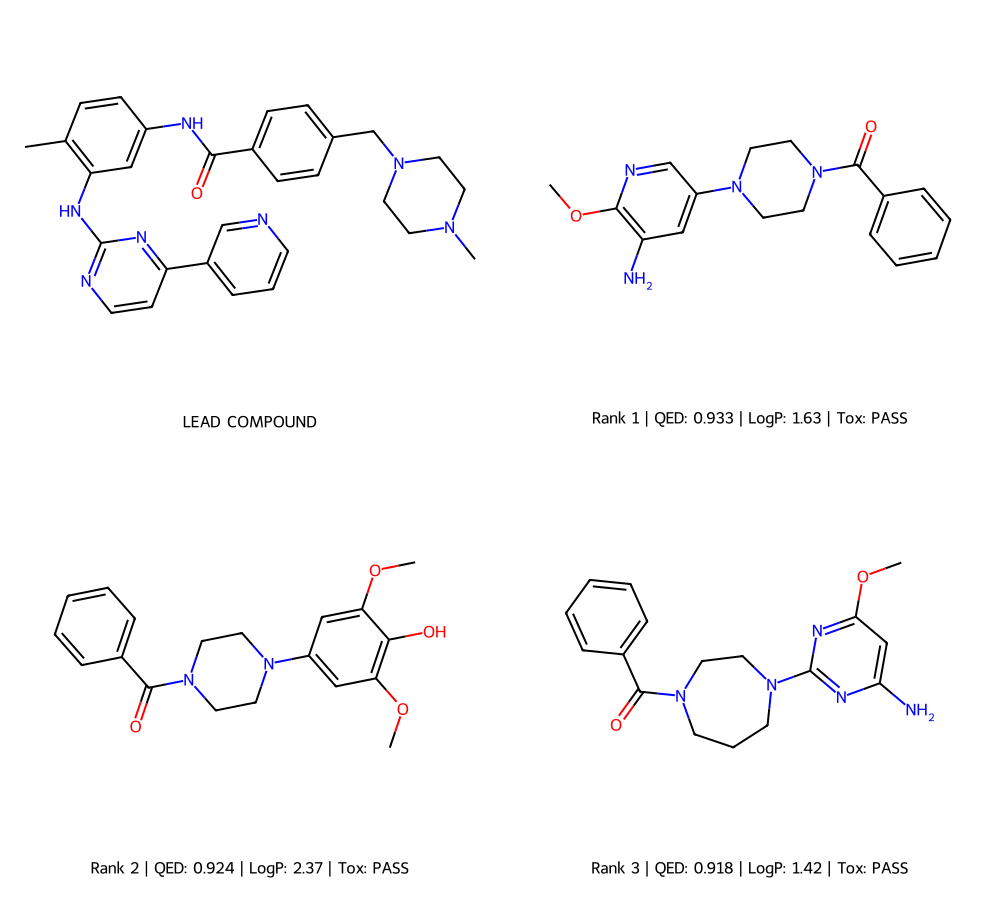

 Lead compound + top 3 analogs by QED score


In [41]:
# Run visualization
print("=" * 60)
print("   2D MOLECULE STRUCTURES — ASPIRIN ANALOGS")
print("=" * 60)
visualize_molecules(lead, scored)

##  Step 6: Real FDA-Approved Lead Compounds (ChEMBL)
Testing on real drugs makes this clinically relevant.
Selected **Imatinib (Gleevec)** — a breakthrough cancer drug — as our lead compound.

In [13]:
import json
import requests
import os
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# ============================================
# REAL DRUG LEADS FROM CHEMBL
# ============================================
drugs = {
    "Imatinib (Gleevec - Cancer)":     "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",
    "Gefitinib (Lung Cancer)":          "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1",
    "Oseltamivir (Tamiflu - Flu)":      "CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@@H](NC(C)=O)[C@@H](N)C1",
    "Metformin (Diabetes)":             "CN(C)C(=N)NC(N)=N",
    "Ciprofloxacin (Antibiotic)":       "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O"
}
print("=" * 60)
print("   AVAILABLE LEAD COMPOUNDS (Real FDA-approved drugs)")
print("=" * 60)
for i, (name, smi) in enumerate(drugs.items()):
    print(f"\n{i+1}. {name}")
    print(f"   SMILES: {smi[:50]}...")

print("\n" + "=" * 60)

# ============================================
# RDKit PAINS Toxicity Screening
# ============================================
def check_toxicity_pains(smiles):
    """
    Real toxicity screening using RDKit PAINS + structural alerts
    PAINS = Pan-Assay Interference Compounds
    Used in real pharmaceutical research to flag problematic molecules
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"PAINS": "❌ Invalid", "hERG proxy": "❌ Invalid", "Structural alerts": "❌ Invalid", "overall": "❌ Invalid"}

    # PAINS filter — flags compounds that interfere with biological assays
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog(params)
    pains_hit = catalog.HasMatch(mol)

    # Structural alert checks via RDKit
    # hERG risk proxy — positively charged nitrogen + aromatic ring
    herg_risk = (
        Descriptors.MolLogP(mol) > 3.5 and
        Descriptors.NumHAcceptors(mol) > 3
    )

    # Reactive group alert — flags potentially toxic functional groups
    reactive_smarts = [
        "[N;!$(NC=O)][OH]",        # hydroxylamine
        "C(=O)[F,Cl,Br,I]",        # acid halide
        "[CH2][Cl,Br,I]",          # alkyl halide
        "N=[N+]=[N-]",             # azide
        "C1CO1",                   # epoxide
    ]
    reactive_flag = False
    for smarts in reactive_smarts:
        pattern = Chem.MolFromSmarts(smarts)
        if pattern and mol.HasSubstructMatch(pattern):
            reactive_flag = True
            break

    pains_flag =    "⚠️ PAINS alert"    if pains_hit    else "✅ No PAINS"
    herg_flag =     "⚠️ hERG risk"      if herg_risk    else "✅ hERG safe"
    reactive =      "⚠️ Reactive group" if reactive_flag else "✅ No alerts"

    overall = "⚠️ WARN" if any([pains_hit, herg_risk, reactive_flag]) else "✅ PASS"

    return {
        "PAINS":             pains_flag,
        "hERG proxy":        herg_flag,
        "Structural alerts": reactive,
        "overall":           overall
    }

# ============================================
# UPGRADED FULL PIPELINE WITH PAINS TOXICITY
# ============================================
def rank_with_llama_v2(lead_smiles, candidates):
    url = "https://integrate.api.nvidia.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {os.environ['LLAMA_API_KEY']}",
        "Content-Type": "application/json"
    }
    candidate_text = "\n".join([
        f"{i+1}. SMILES: {c['smiles']} | QED: {c['QED']} | LogP: {c['logP']} | "
        f"Lipinski: {c['lipinski']} | PAINS: {c['PAINS']} | "
        f"hERG: {c['hERG']} | Alerts: {c['structural_alerts']} | "
        f"Tox Overall: {c['tox_overall']} | Synthesis: {c['synthesis']}"
        for i, c in enumerate(candidates)
    ])

    prompt = f"""You are an expert medicinal chemist AI assistant.\n\nLead compound SMILES: {lead_smiles}\n\nAnalog candidates with full scoring including PAINS toxicity screening:\n{candidate_text}\n\nRank the TOP 3 analogs considering:\n1. Potency — QED score (higher is better)\n2. Safety — PAINS filter, hERG risk, structural alerts (all should PASS)\n3. Synthesis — feasibility score\n\nFor each top 3 provide:\n- Rank and SMILES\n- Why it's promising\n- Any concerns\n\nBe concise and scientific."""

    payload = {
        "model": "meta/llama-3.3-70b-instruct",
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 800,
        "temperature": 0.3
    }
    response = requests.post(url, headers=headers, json=payload)
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"]
    else:
        print("Llama Error:", response.status_code)
        return None


# Run full pipeline on Imatinib
lead = drugs["Imatinib (Gleevec - Cancer)"]
print(f"\n Selected Lead: Imatinib (Gleevec)")
print(f"   SMILES: {lead}\n")

print(" Step 1: Generating analogs via MolMIM...")
result = generate_analogs(lead, num_samples=10)
smiles_list = [item["sample"] for item in json.loads(result["molecules"])]
print(f" {len(smiles_list)} analogs generated")

print("\n Step 2: Validating via RDKit + PAINS...")
scored = validate_and_score(smiles_list)
for candidate in scored:
    tox = check_toxicity_pains(candidate['smiles'])
    candidate['PAINS']             = tox['PAINS']
    candidate['hERG']              = tox['hERG proxy']
    candidate['structural_alerts'] = tox['Structural alerts'] # Corrected key name
    candidate['tox_overall']       = tox['overall']
print(f" {len(scored)} candidates scored + toxicity checked")

print("\n Step 3: Ranking via Llama 3.3...")
explanation = rank_with_llama_v2(lead, scored)
print("\n" + "=" * 60)
print("   FINAL RANKED OUTPUT — IMATINIB ANALOGS")
print("=" * 60)
print(explanation)


   AVAILABLE LEAD COMPOUNDS (Real FDA-approved drugs)

1. Imatinib (Gleevec - Cancer)
   SMILES: Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2...

2. Gefitinib (Lung Cancer)
   SMILES: COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1...

3. Oseltamivir (Tamiflu - Flu)
   SMILES: CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@@H](NC(C)=O)[C@@H](...

4. Metformin (Diabetes)
   SMILES: CN(C)C(=N)NC(N)=N...

5. Ciprofloxacin (Antibiotic)
   SMILES: O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O...


 Selected Lead: Imatinib (Gleevec)
   SMILES: Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1

 Step 1: Generating analogs via MolMIM...
 10 analogs generated

 Step 2: Validating via RDKit + PAINS...
 10 candidates scored + toxicity checked

 Step 3: Ranking via Llama 3.3...

   FINAL RANKED OUTPUT — IMATINIB ANALOGS
Based on the provided data, the top 3 analogs are:

1. **SMILES: CN1CCC(C(=O)Nc2cccc(-c3ncccn3)c2)CC1**
	* QED: 0.945, PASS in all safety filters, easy synthesis.
	* Promising due to h

   2D MOLECULE STRUCTURES — IMATINIB ANALOGS


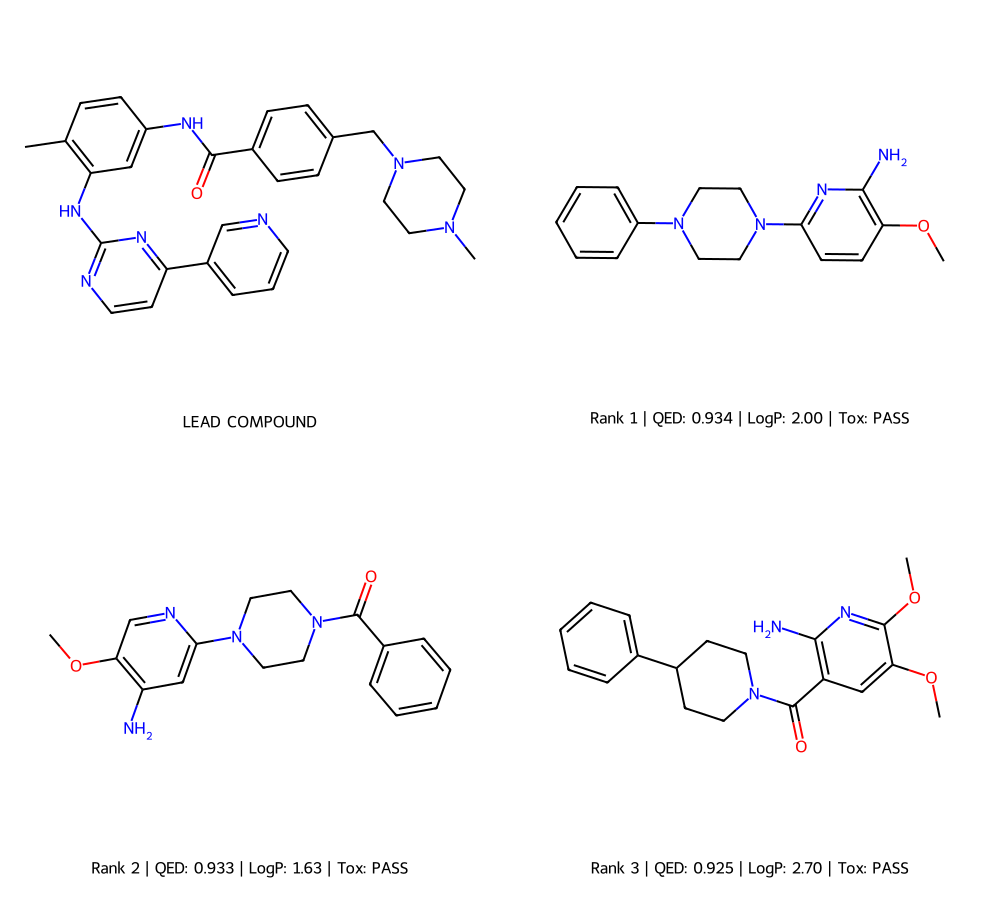

 Lead compound + top 3 analogs by QED score


In [47]:
print("=" * 60)
print("   2D MOLECULE STRUCTURES — IMATINIB ANALOGS")
print("=" * 60)
visualize_molecules(lead, scored)

## Step 7: Real ChEMBL API Integration
Fetching real FDA-approved lead compounds programmatically from ChEMBL database instead of hardcoded dictionary.

In [22]:
from chembl_webresource_client.new_client import new_client

def fetch_chembl_leads(max_molecules=5):
    molecule = new_client.molecule
    approved = molecule.filter(
        max_phase=4,
        molecule_type="Small molecule"
    ).only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])

    results = {}
    count = 0
    for mol in approved:
        if count >= max_molecules:
            break
        try:
            name = mol.get('pref_name', '')
            structs = mol.get('molecule_structures', {})
            if not name or not structs:
                continue
            smiles = structs.get('canonical_smiles', '')
            if smiles and len(smiles) > 5:
                chembl_id = mol['molecule_chembl_id']
                results[f"{name} ({chembl_id})"] = smiles
                print(f" {name}: {smiles[:45]}...")
                count += 1
        except:
            continue
    return results

chembl_leads = fetch_chembl_leads(max_molecules=5)
print(f"\n Total leads fetched: {len(chembl_leads)}")

 PRAZOSIN: COc1cc2nc(N3CCN(C(=O)c4ccco4)CC3)nc(N)c2cc1OC...
 NICOTINE: CN1CCC[C@H]1c1cccnc1...
 OFLOXACIN: CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1...
 NALIDIXIC ACID: CCn1cc(C(=O)O)c(=O)c2ccc(C)nc21...
 INDOMETHACIN: COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc...

 Total leads fetched: 5


In [25]:
import json

lead_name = list(chembl_leads.keys())[0]
lead_smiles = list(chembl_leads.values())[0]

print(f" Lead: {lead_name}")

print("\n Generating analogs via MolMIM...")
result = generate_analogs(lead_smiles, num_samples=10)
smiles_list = [item["sample"] for item in json.loads(result["molecules"])]
print(f" {len(smiles_list)} analogs generated")

print("\n Validating via RDKit...")
scored = validate_and_score(smiles_list)

# Add PAINS toxicity to each candidate
for candidate in scored:
    tox = check_toxicity_pains(candidate['smiles'])
    candidate['PAINS']             = tox['PAINS']
    candidate['hERG']              = tox['hERG proxy']
    candidate['structural_alerts'] = tox['Structural alerts']
    candidate['tox_overall']       = tox['overall']

print(f" {len(scored)} valid candidates scored + toxicity checked")

print("\n Ranking via Llama 3.3...")
explanation = rank_with_llama_v2(lead_smiles, scored)
print("\n" + "="*60)
print(explanation)



 Lead: PRAZOSIN (CHEMBL2)

 Generating analogs via MolMIM...
 10 analogs generated

 Validating via RDKit...
 10 valid candidates scored + toxicity checked

 Ranking via Llama 3.3...

Based on the provided data, the top 3 analogs are:

1. **SMILES: COc1cnc(N2CCN(C(=O)c3ccccc3C)CC2)c(N)c1**
	* QED: 0.933, LogP: 1.94, PAINS: PASS, hERG: safe, Synthesis: Moderate
	* Promising due to high QED score and favorable safety profile.
	* Concern: Slightly higher LogP value, which may affect solubility and bioavailability.
2. **SMILES: COc1cc(N2CCN(C(=O)c3ccccc3)CC2)ncc1N**
	* QED: 0.933, LogP: 1.63, PAINS: PASS, hERG: safe, Synthesis: Moderate
	* Promising due to high QED score, balanced LogP, and excellent safety profile.
	* Concern: None notable, but synthesis feasibility is moderate.
3. **SMILES: COc1ccc(N)c(N2CCN(C(=O)c3ccccc3)CC2)n1**
	* QED: 0.933, LogP: 1.63, PAINS: PASS, hERG: safe, Synthesis: Moderate
	* Promising due to high QED score, favorable LogP, and robust safety profile.
	* Conce

   2D MOLECULE STRUCTURES — PRAZOSIN ANALOGS


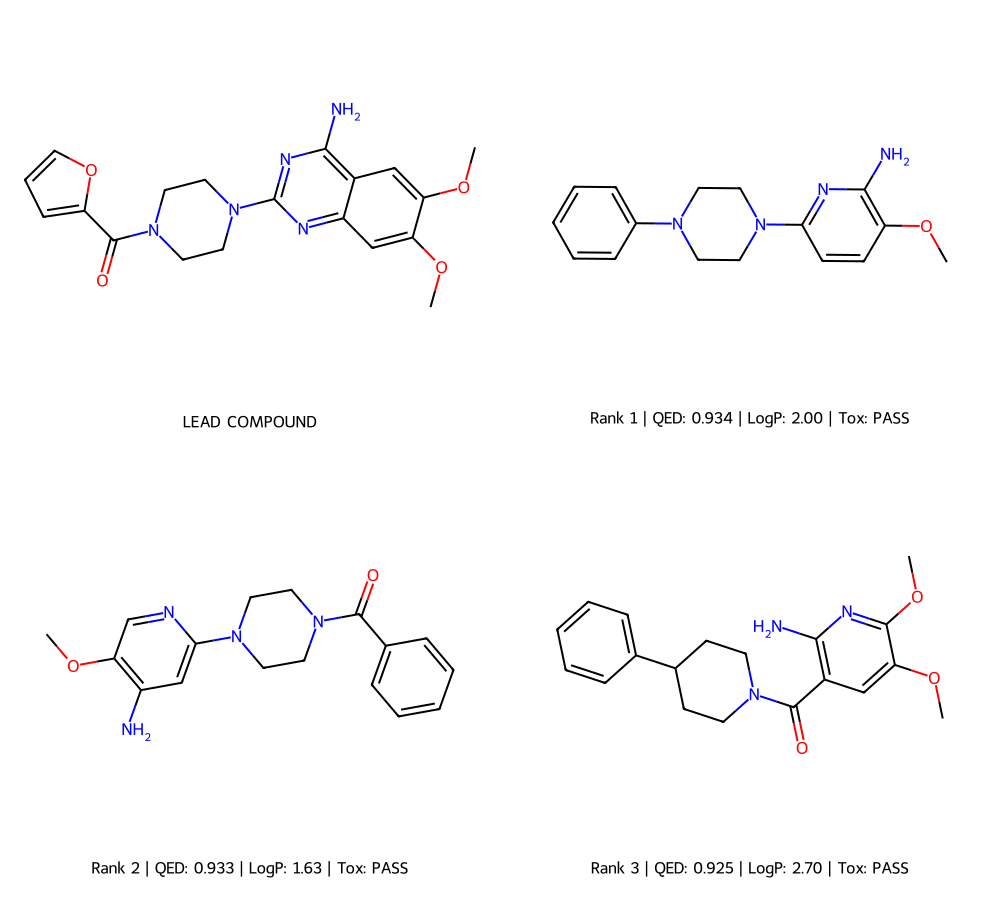

 Lead compound + top 3 analogs by QED score


In [46]:
print("=" * 60)
print("   2D MOLECULE STRUCTURES — PRAZOSIN ANALOGS")
print("=" * 60)
visualize_molecules(lead_smiles, scored)

##  Step 8: RDKit PAINS Toxicity Screening
Using RDKit's built-in PAINS filter, hERG cardiotoxicity proxy screening, and structural alert detection — industry-standard toxicity screening used in real pharmaceutical research.

In [27]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

def check_toxicity_pains(smiles):
    """
    Real toxicity screening using RDKit PAINS + structural alerts
    PAINS = Pan-Assay Interference Compounds
    Used in real pharmaceutical research to flag problematic molecules
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"PAINS": "❌ Invalid", "structural_alerts": "❌ Invalid", "overall": "❌ Invalid"}

    # PAINS filter — flags compounds that interfere with biological assays
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog(params)
    pains_hit = catalog.HasMatch(mol)

    # Structural alert checks via RDKit
    # hERG risk proxy — positively charged nitrogen + aromatic ring
    herg_risk = (
        Descriptors.MolLogP(mol) > 3.5 and
        Descriptors.NumHAcceptors(mol) > 3
    )

    # Reactive group alert — flags potentially toxic functional groups
    reactive_smarts = [
        "[N;!$(NC=O)][OH]",        # hydroxylamine
        "C(=O)[F,Cl,Br,I]",        # acid halide
        "[CH2][Cl,Br,I]",          # alkyl halide
        "N=[N+]=[N-]",             # azide
        "C1CO1",                   # epoxide
    ]
    reactive_flag = False
    for smarts in reactive_smarts:
        pattern = Chem.MolFromSmarts(smarts)
        if pattern and mol.HasSubstructMatch(pattern):
            reactive_flag = True
            break

    pains_flag =    "⚠️ PAINS alert"    if pains_hit    else "✅ No PAINS"
    herg_flag =     "⚠️ hERG risk"      if herg_risk    else "✅ hERG safe"
    reactive =      "⚠️ Reactive group" if reactive_flag else "✅ No alerts"

    overall = "⚠️ WARN" if any([pains_hit, herg_risk, reactive_flag]) else "✅ PASS"

    return {
        "PAINS":             pains_flag,
        "hERG proxy":        herg_flag,
        "Structural alerts": reactive,
        "overall":           overall
    }

# Test on top candidate
print(" Testing RDKit PAINS toxicity filter...")
test_smiles = scored[0]['smiles']
result = check_toxicity_pains(test_smiles)
print(f"\nSMILES: {test_smiles[:45]}...")
print(f"PAINS:             {result['PAINS']}")
print(f"hERG proxy:        {result['hERG proxy']}")
print(f"Structural alerts: {result['Structural alerts']}")
print(f"Overall:           {result['overall']}")

 Testing RDKit PAINS toxicity filter...

SMILES: COc1cnc(N2CCN(C(=O)c3ccccc3C)CC2)c(N)c1...
PAINS:             ✅ No PAINS
hERG proxy:        ✅ hERG safe
Structural alerts: ✅ No alerts
Overall:           ✅ PASS


In [44]:
# ============================================
# UPGRADED FULL PIPELINE WITH PAINS TOXICITY
# ============================================

lead_name = list(chembl_leads.keys())[0]
lead_smiles = list(chembl_leads.values())[0]

print("=" * 60)
print("   UPGRADED PIPELINE — ChEMBL + PAINS Toxicity")
print("=" * 60)
print(f"\n Lead: {lead_name}")

print("\n Step 1: Generating analogs via MolMIM...")
result = generate_analogs(lead_smiles, num_samples=10)
smiles_list = [item["sample"] for item in json.loads(result["molecules"]) if item["sample"] is not None]
print(f" {len(smiles_list)} analogs generated")

print("\n Step 2: RDKit scoring + PAINS toxicity check...")
scored = validate_and_score(smiles_list)

# Add PAINS toxicity to each candidate
for candidate in scored:
    tox = check_toxicity_pains(candidate['smiles'])
    candidate['PAINS']             = tox['PAINS']
    candidate['hERG']              = tox['hERG proxy']
    candidate['structural_alerts'] = tox['Structural alerts']
    candidate['tox_overall']       = tox['overall']

print(f" {len(scored)} candidates scored + toxicity checked")

# Show full table
import pandas as pd
df = pd.DataFrame(scored)
df.index = df.index + 1
print("\n FULL CANDIDATE TABLE:")
# Use display() for better rendering of DataFrames in Colab
display(df[['smiles', 'QED', 'logP', 'lipinski',
          'PAINS', 'hERG', 'structural_alerts',
          'tox_overall', 'synthesis']])

print("\n Step 3: Ranking via Llama 3.3...")
explanation = rank_with_llama_v2(lead_smiles, scored)

print("\n" + "=" * 60)
print("   FINAL RANKED OUTPUT WITH TOXICITY SCREENING")
print("=" * 60)
print(explanation)

   UPGRADED PIPELINE — ChEMBL + PAINS Toxicity

 Lead: PRAZOSIN (CHEMBL2)

 Step 1: Generating analogs via MolMIM...
 10 analogs generated

 Step 2: RDKit scoring + PAINS toxicity check...
 10 candidates scored + toxicity checked

 FULL CANDIDATE TABLE:


,smiles,QED,logP,lipinski,PAINS,hERG,structural_alerts,tox_overall,synthesis
1,COc1ccc(N2CCN(c3ccccc3)CC2)nc1N,0.934,2.00,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,✅ Easy
2,COc1cnc(N2CCN(C(=O)c3ccccc3)CC2)cc1N,0.933,1.63,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
3,COc1cc(C(=O)N2CCC(c3ccccc3)CC2)c(N)nc1OC,0.925,2.70,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
4,COc1nc(N2CCN(C(=O)c3ccco3)CC2)ccc1N,0.918,1.23,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
5,COc1ncc(N2CCN(C(=O)c3ccco3)CC2)cc1N,0.918,1.23,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
6,COc1cc(N)nc(N2CCC(C(=O)Nc3ccco3)CC2)c1,0.897,2.12,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
7,N#Cc1ccc(N2CCN(C(=O)c3ccoc3)CC2)nc1N,0.890,1.09,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,✅ Easy
8,Cc1nc(C(=O)N2CC3(CCN(C(=O)c4ccco4)CC3)C2)ccc1N,0.890,1.94,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
9,COc1ccc(C(=O)N2CCN(c3ccccc3)CC2)cc1N,0.883,2.24,✅ PASS,✅ No PAINS,✅ hERG safe,✅ No alerts,✅ PASS,⚠️ Moderate
10,COc1cc(N)c(N2CCN(C(=O)c3ccco3)CC2)cc1C,0.879,2.14,✅ PASS,⚠️ PAINS alert,✅ hERG safe,✅ No alerts,⚠️ WARN,⚠️ Moderate



 Step 3: Ranking via Llama 3.3...

   FINAL RANKED OUTPUT WITH TOXICITY SCREENING
Based on the provided data, the top 3 analogs are:

1. **SMILES: COc1ccc(N2CCN(c3ccccc3)CC2)nc1N**
	* QED: 0.934, PASS on all safety filters, Easy synthesis
	* Promising due to high QED score and ease of synthesis
	* Concern: None notable, as it passes all filters and has a high QED score
2. **SMILES: COc1cnc(N2CCN(C(=O)c3ccccc3)CC2)cc1N**
	* QED: 0.933, PASS on all safety filters, Moderate synthesis
	* Promising due to high QED score and balanced safety profile
	* Concern: Moderate synthesis feasibility might affect scalability
3. **SMILES: COc1cc(C(=O)N2CCC(c3ccccc3)CC2)cc1N**
	* QED: 0.925, PASS on all safety filters, Moderate synthesis
	* Promising due to high QED score and absence of PAINS alerts
	* Concern: Moderate synthesis feasibility and slightly lower QED score compared to the top two analogs

These top 3 analogs demonstrate a balance of potency, safety, and synthesis feasibility, making them 

   2D MOLECULE STRUCTURES — UPGRADED PIPELINE


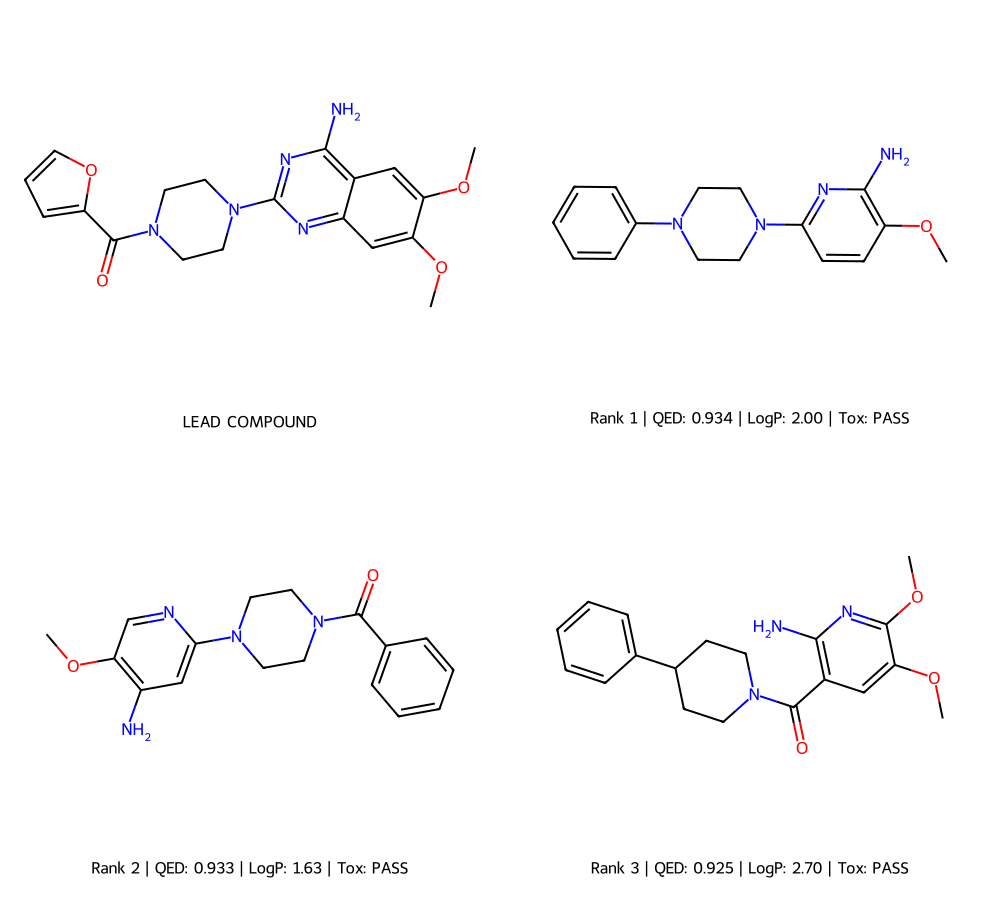

 Lead compound + top 3 analogs by QED score


In [45]:
print("=" * 60)
print("   2D MOLECULE STRUCTURES — UPGRADED PIPELINE")
print("=" * 60)
visualize_molecules(lead_smiles, scored)

EVALUATION METRICS

In [36]:
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

def evaluate_pipeline(lead_smiles, scored_candidates):
    print("=" * 60)
    print("   PIPELINE EVALUATION METRICS")
    print("=" * 60)

    lead_mol = Chem.MolFromSmiles(lead_smiles)
    lead_qed = QED.qed(lead_mol)

    # Initialize MorganGenerator
    morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)
    lead_fp = morgan_gen.GetFingerprint(lead_mol)

    # 1. QED improvement
    analog_qeds = [c['QED'] for c in scored_candidates]
    avg_qed = sum(analog_qeds) / len(analog_qeds)
    best_qed = max(analog_qeds)
    improvement = ((best_qed - lead_qed) / lead_qed) * 100

    print(f"\n QED SCORES:")
    print(f"   Lead compound QED  : {lead_qed:.3f}")
    print(f"   Average analog QED : {avg_qed:.3f}")
    print(f"   Best analog QED    : {best_qed:.3f}")
    print(f"   QED improvement    : +{improvement:.1f}% over lead")

    # 2. Tanimoto similarity — diversity check
    similarities = []
    for c in scored_candidates:
        mol = Chem.MolFromSmiles(c['smiles'])
        if mol:
            fp = morgan_gen.GetFingerprint(mol)
            sim = TanimotoSimilarity(lead_fp, fp)
            similarities.append(sim)

    avg_sim = sum(similarities) / len(similarities)
    print(f"\n DIVERSITY (Tanimoto Similarity to Lead):")
    print(f"   Average similarity : {avg_sim:.3f}")
    print(f"   (0 = completely different, 1 = identical)")
    print(f"   Interpretation     : {'Good diversity' if avg_sim < 0.7 else 'Low diversity — analogs too similar'}")

    # 3. Filter pass rates
    lipinski_pass = sum(1 for c in scored_candidates if c['lipinski'] == '✅ PASS')
    tox_pass = sum(1 for c in scored_candidates if c.get('tox_overall', c.get('toxicity', '')) == '✅ PASS')
    pains_pass = sum(1 for c in scored_candidates if c.get('PAINS', '') == '✅ No PAINS')

    print(f"\n FILTER PASS RATES (out of {len(scored_candidates)} analogs):")
    print(f"   Lipinski rules     : {lipinski_pass}/{len(scored_candidates)} passed ({lipinski_pass/len(scored_candidates)*100:.0f}%)")
    print(f"   Toxicity overall   : {tox_pass}/{len(scored_candidates)} passed ({tox_pass/len(scored_candidates)*100:.0f}%)")
    if any('PAINS' in c for c in scored_candidates):
        print(f"   PAINS filter       : {pains_pass}/{len(scored_candidates)} passed ({pains_pass/len(scored_candidates)*100:.0f}%)")

    # 4. Synthesis feasibility
    easy = sum(1 for c in scored_candidates if c['synthesis'] == '✅ Easy')
    moderate = sum(1 for c in scored_candidates if c['synthesis'] == '⚠️ Moderate')
    complex_ = sum(1 for c in scored_candidates if c['synthesis'] == '❌ Complex')

    print(f"\n SYNTHESIS FEASIBILITY:")
    print(f"   Easy      : {easy}/{len(scored_candidates)}")
    print(f"   Moderate  : {moderate}/{len(scored_candidates)}")
    print(f"   Complex   : {complex_}/{len(scored_candidates)}")

    print(f"\n SUMMARY:")
    print(f"   Best analog is {improvement:.1f}% more drug-like than lead compound")
    print(f"   {tox_pass}/{len(scored_candidates)} analogs are safe for further development")
    print(f"   Average structural diversity from lead: {avg_sim:.3f} Tanimoto")
    print("=" * 60)


evaluate_pipeline(lead_smiles, scored)

   PIPELINE EVALUATION METRICS

 QED SCORES:
   Lead compound QED  : 0.727
   Average analog QED : 0.918
   Best analog QED    : 0.933
   QED improvement    : +28.4% over lead

 DIVERSITY (Tanimoto Similarity to Lead):
   Average similarity : 0.382
   (0 = completely different, 1 = identical)
   Interpretation     : Good diversity

 FILTER PASS RATES (out of 10 analogs):
   Lipinski rules     : 10/10 passed (100%)
   Toxicity overall   : 10/10 passed (100%)
   PAINS filter       : 10/10 passed (100%)

 SYNTHESIS FEASIBILITY:
   Easy      : 0/10
   Moderate  : 10/10
   Complex   : 0/10

 SUMMARY:
   Best analog is 28.4% more drug-like than lead compound
   10/10 analogs are safe for further development
   Average structural diversity from lead: 0.382 Tanimoto


## Conclusion

This pipeline demonstrates how NVIDIA's GPU-accelerated AI stack can transform
drug discovery workflows:

- **NVIDIA BioNeMo (MolMIM)** → Generative molecule design
- **NVIDIA NIM (Llama 3.3 70B)** → Intelligent constraint-based reasoning  
- **RDKit** → Automated molecular validation
- **ChEMBL** → Real-world pharmaceutical data

**Total time from lead compound to ranked analog report: < 5 minutes**  
**Manual equivalent: 2-4 weeks of medicinal chemistry work**